In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Part 1)

In [2]:
penguins = pd.read_csv('penguins.csv')

peng = penguins.dropna(subset=['flipper_length_mm', 'body_mass_g', 'bill_length_mm', 'bill_depth_mm']).reset_index(drop=True)
print(f"n = {len(peng)}")

n = 342


### A)

r = -0.4719
R-squared = 0.2227


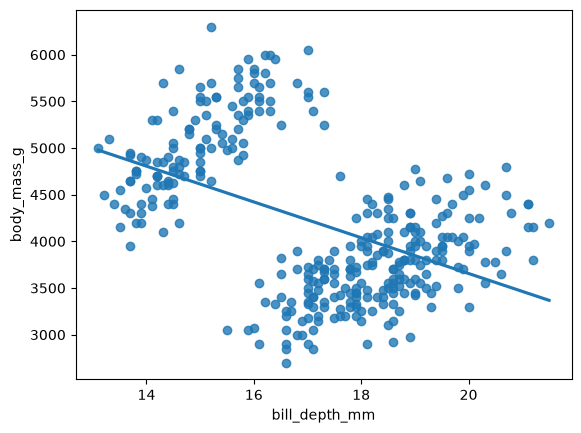

In [4]:
sns.regplot(data=peng, x='bill_depth_mm', y='body_mass_g', ci=None)
r = peng['bill_depth_mm'].corr(peng['body_mass_g'])
print(f"r = {r:.4f}")
print(f"R-squared = {r**2:.4f}")

Body mass and bill depth have a weak negative correlation, with r = -0.4719 and R2 = 0.2227, so bill depth only explains about 22 percent of the variation in body mass. This is unexpected because I would expect proportions to scale up with weight, meaning heavier penguins should have deeper bills. Looking at the scatter plot itself there do appear to be two separate clusters, which suggests the overall trend may be hiding something.

### B)

In [5]:
import numpy as np

x = peng['bill_depth_mm']
y = peng['body_mass_g']

x_bar, y_bar = x.mean(), y.mean()

b1 = ((x - x_bar) * (y - y_bar)).sum() / ((x - x_bar) ** 2).sum()
b0 = y_bar - b1 * x_bar

print(f"b0 = {b0:.4f}, b1 = {b1:.4f}")
print(f"body_mass_g = {b0:.2f} + {b1:.2f} * bill_depth_mm")

b0 = 7488.6524, b1 = -191.6428
body_mass_g = 7488.65 + -191.64 * bill_depth_mm


The estimated regression equation is body_mass_g = 7488.65 + -191.64 * bill_depth_mm.
The slope of -191.6428 means that for every one mm increase in bill depth there is on average a 191.64 gram decrease in body mass.

### C)

In [6]:
y_hat = b0 + b1 * x

rse = np.sqrt(((y - y_hat) ** 2).sum() / (len(peng) - 2))
print(f"RSE = {rse:.2f}")

r = x.corr(y)
print(f"R-squared = {r**2:.4f}")

RSE = 708.08
R-squared = 0.2227


RSE is telling us that our model has a typical prediction error of 708.08 grams when using bill depth to predict mass. The R-squared of 0.2227 means that 22.27 percent of the variation in mass is explained by the bill depth.

# Part 2)

### A)

In [9]:
X = sm.add_constant(peng['bill_depth_mm'])
y = peng['body_mass_g']

results = sm.OLS(y, X).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.223
Model:                            OLS   Adj. R-squared:                  0.220
Method:                 Least Squares   F-statistic:                     97.41
Date:                Sun, 13 Sep 2026   Prob (F-statistic):           2.28e-20
Time:                        14:20:54   Log-Likelihood:                -2728.7
No. Observations:                 342   AIC:                             5461.
Df Residuals:                     340   BIC:                             5469.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          7488.6524    335.218     22.340

ANSWER:
For the slope, the standard error is 19.417, the t-statistic is -9.870, and the p-value is less
than 0.001.
H0 is that the slope is zero, meaning bill depth has no linear relationship with body mass.
H1 is that the slope is not zero, meaning bill depth does have a linear relationship with body mass.
Since t = -9.870 and the p-value is less than 0.001, we reject H0 and conclude that bill depth has
a statistically significant negative relationship with body mass.

### B)

ANSWER:
The R-squared of 0.223 means that 22.3 percent of the variation in body mass is explained by
bill depth, so the model is weak. The p-value for the slope is less than 0.001, which means the
model has very high confidence that there is a negative relationship between bill depth and body
mass. The p-value does not relate to the strength of the relationship, which is why an R-squared
of 0.223 is still consistent with a very low p-value. With n = 342 the test can detect even a
weak relationship, so the relationship is real but weak.

### C)

In [10]:
x = peng['bill_depth_mm']
y = peng['body_mass_g']
xv, yv = x.to_numpy(), y.to_numpy()

rng = np.random.default_rng(42)
n_boot = 10000
n = len(peng)
boot = np.empty((n_boot, 2))

for i in range(n_boot):
    idx = rng.integers(0, n, n)
    xb, yb = xv[idx], yv[idx]
    xm, ym = xb.mean(), yb.mean()
    slope = ((xb - xm) * (yb - ym)).sum() / ((xb - xm) ** 2).sum()
    boot[i] = (ym - slope * xm, slope)

boot_df = pd.DataFrame(boot, columns=['b0', 'b1'])

analytic_ci = results.conf_int()
comparison = pd.DataFrame({
    'estimate (full sample)': [b0, b1],
    'bootstrap mean':         [boot_df['b0'].mean(), boot_df['b1'].mean()],
    'CI low (formula)':       analytic_ci[0].to_numpy(),
    'CI low (bootstrap)':     [boot_df['b0'].quantile(.025), boot_df['b1'].quantile(.025)],
    'CI high (formula)':      analytic_ci[1].to_numpy(),
    'CI high (bootstrap)':    [boot_df['b0'].quantile(.975), boot_df['b1'].quantile(.975)],
}, index=['b0', 'b1'])

comparison.round(3).T

,b0,b1
estimate (full sample),7488.652,-191.643
bootstrap mean,7496.018,-192.057
CI low (formula),6829.290,-229.835
CI low (bootstrap),6959.090,-223.878
CI high (formula),8148.014,-153.450
CI high (bootstrap),8059.257,-161.913


For both b0 and b1 the bootstrap confidence interval is narrower than the statsmodels interval.
This tells us that the formula-based interval is more conservative here. The formula interval
relies on its normality assumption for the shape of the distribution, while the bootstrap only
uses the spread the data itself shows when resampled.

In [11]:
def run_bootstrap(B, seed):
    rng = np.random.default_rng(seed)
    boot = np.empty((B, 2))
    for i in range(B):
        idx = rng.integers(0, n, n)
        xb, yb = xv[idx], yv[idx]
        xm, ym = xb.mean(), yb.mean()
        slope = ((xb - xm) * (yb - ym)).sum() / ((xb - xm) ** 2).sum()
        boot[i] = (ym - slope * xm, slope)
    boot_df = pd.DataFrame(boot, columns=['b0', 'b1'])
    return (boot_df['b0'].quantile(.025), boot_df['b0'].quantile(.975),
            boot_df['b1'].quantile(.025), boot_df['b1'].quantile(.975))

rows = []
seed = 100
for B in [100, 1000, 10000]:
    for run in range(10):
        lo0, hi0, lo1, hi1 = run_bootstrap(B, seed)
        rows.append({'B': B, 'run': run + 1,
                     'b0 lo': lo0, 'b0 hi': hi0,
                     'b1 lo': lo1, 'b1 hi': hi1})
        seed += 1

boot_runs = pd.DataFrame(rows)
print(boot_runs.round(2).to_string())

        B  run    b0 lo    b0 hi   b1 lo   b1 hi
0     100    1  6894.19  7943.76 -217.63 -158.64
1     100    2  6988.50  8028.46 -219.58 -163.28
2     100    3  6922.04  8048.08 -222.83 -159.88
3     100    4  6940.07  7935.47 -217.83 -161.37
4     100    5  7003.28  8160.03 -230.27 -163.21
5     100    6  7007.73  8055.36 -222.83 -163.72
6     100    7  7058.46  8075.63 -224.77 -165.50
7     100    8  6986.54  7995.74 -219.71 -164.62
8     100    9  6972.20  8040.68 -223.07 -164.01
9     100   10  7043.12  8085.44 -227.45 -166.96
10   1000    1  6990.80  8011.83 -220.62 -162.67
11   1000    2  6962.66  8024.85 -221.72 -161.71
12   1000    3  6939.41  8058.03 -223.35 -161.60
13   1000    4  6980.76  8058.02 -224.58 -162.61
14   1000    5  6987.44  8017.69 -222.84 -164.22
15   1000    6  6970.32  8054.03 -223.38 -163.47
16   1000    7  6931.65  8035.78 -222.88 -161.86
17   1000    8  6983.42  8072.05 -224.78 -163.58
18   1000    9  6926.01  8023.17 -221.96 -161.27
19   1000   10  6978

The larger B is, the more stable the confidence intervals are from one simulation to the next. In the table the b1 lower bound swings by about 13 grams across the 10 repetitions at B = 100, about 4 grams at B = 1000, and less than 2 grams at B = 10000. The width of the interval itself settles down rather than continuing to shrink, so the benefit of a larger B is stability, not tighter intervals. Computation time scales linearly with B since every simulation costs the same to run, so there are diminishing returns, and B = 10000 is already stable enough that repeating the bootstrap gives nearly identical intervals.

# Part 3)

### A)

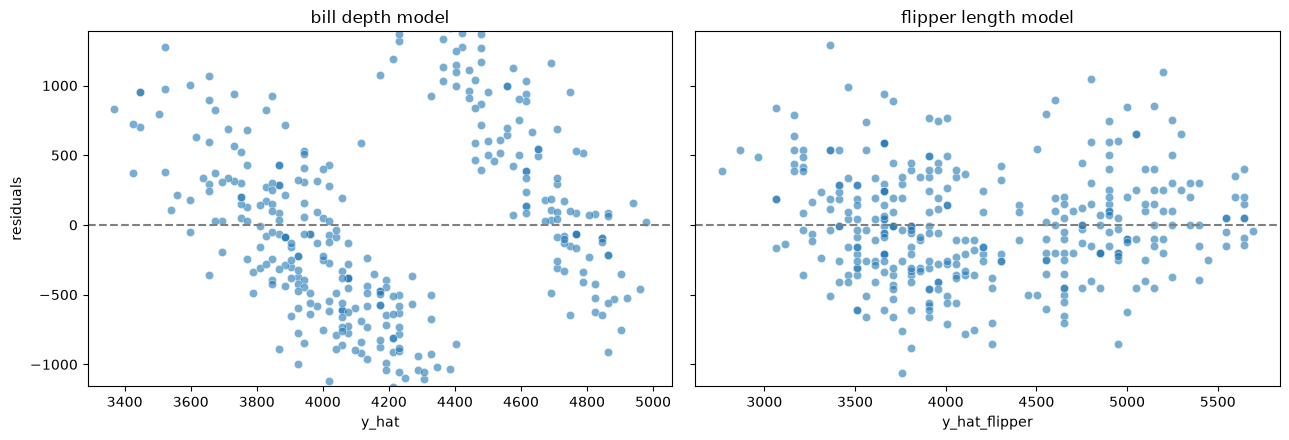

In [12]:
simple = sm.OLS(peng['body_mass_g'],
                sm.add_constant(peng['flipper_length_mm'])).fit()
peng['y_hat_flipper'] = simple.fittedvalues
peng['residuals_flipper'] = simple.resid

peng['y_hat'] = results.fittedvalues
peng['residuals'] = results.resid

resid_ylim = (peng['residuals_flipper'].min() - 100, peng['residuals_flipper'].max() + 100)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
sns.scatterplot(data=peng, x='y_hat', y='residuals', alpha=0.6, ax=axes[0])
axes[0].axhline(0, color='gray', ls='--')
axes[0].set_title('bill depth model')
sns.scatterplot(data=peng, x='y_hat_flipper', y='residuals_flipper', alpha=0.6, ax=axes[1])
axes[1].axhline(0, color='gray', ls='--')
axes[1].set_title('flipper length model')
axes[1].set_ylim(resid_ylim)
plt.tight_layout()